## Title: Survival Analysis of Home Run Droughts in MLB
DSC 680: Applied Data Science | Bellevue University  
Author: Nana Noda-Morgan  
Date: 15 May 2026  
Modified by: Nana Noda-Morgan  
  
## Project Overview
Fernando Tatis Jr. entered the 2026 MLB season as one of the most feared power hitters in baseball. Yet through the first 42+ games, he had zero home runs — an anomaly made stranger by the fact that his underlying contact metrics (exit velocity, barrel rate, hard-hit rate) remained elite. How do you hit the ball that hard and have nothing to show for it in the home run column?

This notebook applies **survival analysis** to model home run droughts among power hitters in MLB. Rather than asking "will he hit a home run," we ask a more statistically interesting question: *given a hitter's batted ball profile, how long should we expect a drought to last before the event occurs?*

Tatis Jr. serves as the motivating case study, but the analysis is built on a population of power hitters dating back to 2015 (the start of Statcast tracking), making the findings generalizable beyond a single player or season.

## Research Questions
1. How long do home run droughts typically last for high-power hitters, measured in plate appearances?
2. Which Statcast metrics (exit velocity, launch angle, barrel rate, pull rate, chase rate) are most predictive of drought duration?
3. Is Tatis Jr.'s 2026 drought statistically unusual given his underlying profile, or within the expected range?
4. At what point does a drought become a signal worth investigating rather than routine variance?

## Methods
- **Kaplan-Meier survival curves** for exploratory analysis of drought duration by player tier
- **Cox Proportional Hazards model** to estimate the effect of Statcast covariates on time-to-home-run
- **Schoenfeld residuals** to test the proportional hazards assumption
- All plate appearance data sourced via `pybaseball` (Statcast + FanGraphs)

In [9]:
import subprocess
import sys

# Install lifelines into the current Jupyter kernel's Python environment.
subprocess.check_call([sys.executable, "-m", "pip", "install", "lifelines"])

0

In [11]:
# Environment setup and imports

# Core data manipulation libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Survival analysis — lifelines is the primary Python library for
# Kaplan-Meier estimation and Cox Proportional Hazards modeling
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test  # used to compare survival curves across groups
from lifelines.utils import concordance_index   # model evaluation metric for survival models

# pybaseball provides clean access to Statcast and FanGraphs data
# via public MLB APIs without requiring manual downloads
import pybaseball
from pybaseball import statcast_batter, playerid_lookup, batting_stats

# Suppress pandas and lifelines deprecation warnings for cleaner notebook output
import warnings
warnings.filterwarnings('ignore')

# Widen column display so Statcast DataFrames don't truncate in notebook view
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.3f}'.format)

print("All libraries loaded successfully.")
print(f"pybaseball version: {pybaseball.__version__}")

All libraries loaded successfully.
pybaseball version: 2.2.7


In [13]:
# Look up Fernando Tatis Jr.'s MLB Player ID using pybaseball
# playerid_lookup returns a DataFrame of matched players
# we need his MLBAM ID specifically, which is the key used by Statcast for all player-level queries.

try:
    tatis_lookup = playerid_lookup('tatis', 'fernando')
    print(tatis_lookup[['name_last', 'name_first', 'mlbam', 'birthdate']])
except Exception as e:
    print(f"Lookup failed: {e}")

Gathering player lookup table. This may take a moment.
Lookup failed: "['mlbam', 'birthdate'] not in index"


In [15]:
try:
    tatis_lookup = playerid_lookup('tatis', 'fernando')
    print(tatis_lookup.columns.tolist())
    print(tatis_lookup)
except Exception as e:
    print(f"Lookup failed: {e}")

['name_last', 'name_first', 'key_mlbam', 'key_retro', 'key_bbref', 'key_fangraphs', 'mlb_played_first', 'mlb_played_last']
Empty DataFrame
Columns: [name_last, name_first, key_mlbam, key_retro, key_bbref, key_fangraphs, mlb_played_first, mlb_played_last]
Index: []


In [19]:
##This should return both Tatis Sr and Tatis Jr.

try:
    tatis_lookup = playerid_lookup('tatis')
    print(tatis_lookup[['name_last', 'name_first', 'key_mlbam', 'mlb_played_first', 'mlb_played_last']])
except Exception as e:
    print(f"Lookup failed: {e}")

Empty DataFrame
Columns: [name_last, name_first, key_mlbam, mlb_played_first, mlb_played_last]
Index: []


In [21]:
# Fernando Tatis Jr.'s MLBAM ID sourced directly from Baseball Savant:
# https://baseballsavant.mlb.com/savant-player/fernando-tatis-jr-665487
# The ID is the numeric suffix in that URL — this is the standard
# player identifier used across all Statcast queries.
TATIS_ID = 665487

print(f"Fernando Tatis Jr. MLBAM ID: {TATIS_ID}")

Fernando Tatis Jr. MLBAM ID: 665487


In [23]:
# Pull all available Statcast plate appearance data for Tatis Jr.
# Statcast data begins in 2015, so that is our starting point, through the current 2026 season to capture his ongoing drought.
# statcast_batter() returns one row per pitch, so we will need to filter down to one row per plate appearance in a later step.

# pybaseball caching speeds up repeated data pulls during development
pybaseball.cache.enable()

try:
    tatis_statcast = statcast_batter('2015-01-01', '2026-12-31', player_id=TATIS_ID)
    print(f"Rows returned: {len(tatis_statcast)}")
    print(f"Columns returned: {len(tatis_statcast.columns)}")
    print(f"\nDate range: {tatis_statcast['game_date'].min()} to {tatis_statcast['game_date'].max()}")
    print(f"\nSeason breakdown:")
    print(tatis_statcast.groupby('game_year')['game_date'].count().rename('pitch_count'))
except Exception as e:
    print(f"Data pull failed: {e}")

Gathering Player Data
Rows returned: 12814
Columns returned: 118

Date range: 2017-03-06 to 2026-05-14

Season breakdown:
game_year
2017       5
2018      74
2019    1558
2020    1146
2021    2236
2023    2450
2024    1726
2025    2837
2026     782
Name: pitch_count, dtype: int64


## Data Source

Statcast pitch-level data for Fernando Tatis Jr. was pulled using `pybaseball.statcast_batter()`, 
covering 2015 through the current 2026 season (his MLBAM ID is 665487). The dataset returned 12,814 
rows across 118 columns, where each row represents a single pitch.

Notable observations:
- Data begins in 2019 in meaningful volume; 2017 and 2018 rows reflect limited spring training or
minor league appearances and will be filtered to MLB regular season only
- 2022 is absent entirely, consistent with Tatis' season-long absence due to his 80 game PED suspension and injury
- 2026 captures 782 pitches through May 14, covering his current 42-game homerless stretch

In [26]:
# Filter the pitch-level data down to one row per plate appearance.
# Each plate appearance ends on a terminal event. Keep only the final pitch of each PA using the 'events' column, which is
# populated only on the last pitch and null on all others. I will also restrict to regular season games only (game_type == 'R')
# and drop the sparse 2017/2018 rows where Statcast coverage was limited to spring training and minor league appearances.


try:
    # Keep only rows where a plate appearance outcome was recorded
    tatis_pa = tatis_statcast[tatis_statcast['events'].notna()].copy()

    # Restrict to regular season games only
    tatis_pa = tatis_pa[tatis_pa['game_type'] == 'R'].copy()

    # Drop pre-2019 rows due to inconsistent Statcast coverage
    tatis_pa = tatis_pa[tatis_pa['game_year'] >= 2019].copy()

    # Sort chronologically for drought episode construction later
    tatis_pa = tatis_pa.sort_values(['game_date', 'at_bat_number']).reset_index(drop=True)

    print(f"Total plate appearances: {len(tatis_pa)}")
    print(f"\nSeason breakdown:")
    print(tatis_pa.groupby('game_year')['events'].count().rename('pa_count'))
    print(f"\nSample of event types:")
    print(tatis_pa['events'].value_counts().head(10))
except Exception as e:
    print(f"Filter failed: {e}")

Total plate appearances: 3122

Season breakdown:
game_year
2019    372
2020    258
2021    547
2023    635
2024    438
2025    692
2026    180
Name: pa_count, dtype: int64

Sample of event types:
events
field_out                    1104
strikeout                     730
single                        452
walk                          295
home_run                      152
double                        141
force_out                      61
grounded_into_double_play      50
hit_by_pitch                   29
field_error                    25
Name: count, dtype: int64


## Data Preparation: Filtering to Plate Appearances

The raw Statcast data was filtered from pitch-level to plate appearance level by keeping only 
rows where the `events` column is populated. This field is recorded only on the final pitch 
of each plate appearance. Additional filters applied:

- **Regular season only** (`game_type == 'R'`) to exclude spring training and postseason
- **2019 onward** to ensure consistent Statcast coverage

This yielded **3,122 plate appearances** across 6 seasons (2019, 2020, 2021, 2023, 2024, 2025, 2026).
The most common outcomes are field outs (1,104) and strikeouts (730), consistent with Tatis' 
high-strikeout, high-power profile. His 152 career home runs in this dataset provide a sufficient 
number of events for survival modeling.

In [29]:
# Prepare the core columns needed for survival analysis.
# I create a binary event indicator (1 = home run, 0 = all other outcomes) and select the Statcast covariates identified during project scoping:
# exit velocity, launch angle, barrel flag, pull rate proxy, and plate discipline metrics.


try:
    # Binary event indicator. This is the survival "event" we are modeling
    tatis_pa['is_home_run'] = (tatis_pa['events'] == 'home_run').astype(int)

    # Confirm home run counts match the season breakdown expected
    print("Home runs by season:")
    print(tatis_pa.groupby('game_year')['is_home_run'].sum())

    # Preview the Statcast columns most relevant to our covariate set
    # to confirm they are populated and understand their coverage
    covariate_cols = [
        'launch_speed',       # exit velocity in mph
        'launch_angle',       # vertical launch angle in degrees
        'barrel',             # binary: 1 if batted ball meets barrel criteria
        'hit_distance_sc',    # projected hit distance
        'hc_x',               # hit coordinate x — used to derive pull direction
        'hc_y',               # hit coordinate y — used to derive pull direction
        'estimated_woba_using_speedangle',  # xwOBA — expected outcome based on EV and LA
        'sz_top',             # top of strike zone (batter-specific)
        'plate_z',            # vertical pitch location
        'plate_x',            # horizontal pitch location
    ]

    print(f"\nCovariate null counts (out of {len(tatis_pa)} PAs):")
    print(tatis_pa[covariate_cols].isnull().sum())

except Exception as e:
    print(f"Feature creation failed: {e}")

Home runs by season:
game_year
2019    22
2020    17
2021    42
2023    25
2024    21
2025    25
2026     0
Name: is_home_run, dtype: int32

Covariate null counts (out of 3122 PAs):
Feature creation failed: "['barrel'] not in index"


In [31]:
##Check what the barrel column is actually called:
# Printing all column names to identify the correct Statcast field names
# for barrel and other batted ball metrics in this version of pybaseball
print(sorted(tatis_statcast.columns.tolist()))

['age_bat', 'age_bat_legacy', 'age_pit', 'age_pit_legacy', 'api_break_x_arm', 'api_break_x_batter_in', 'api_break_z_with_gravity', 'arm_angle', 'at_bat_number', 'attack_angle', 'attack_direction', 'away_score', 'away_team', 'ax', 'ay', 'az', 'babip_value', 'balls', 'bat_score', 'bat_score_diff', 'bat_speed', 'bat_win_exp', 'batter', 'batter_days_since_prev_game', 'batter_days_until_next_game', 'bb_type', 'break_angle_deprecated', 'break_length_deprecated', 'delta_home_win_exp', 'delta_pitcher_run_exp', 'delta_run_exp', 'des', 'description', 'effective_speed', 'estimated_ba_using_speedangle', 'estimated_slg_using_speedangle', 'estimated_woba_using_speedangle', 'events', 'fielder_2', 'fielder_3', 'fielder_4', 'fielder_5', 'fielder_6', 'fielder_7', 'fielder_8', 'fielder_9', 'fld_score', 'game_date', 'game_pk', 'game_type', 'game_year', 'hc_x', 'hc_y', 'hit_distance_sc', 'hit_location', 'home_score', 'home_score_diff', 'home_team', 'home_win_exp', 'hyper_speed', 'if_fielding_alignment', 'i

In [33]:
# Prepare the core columns needed for survival analysis.
# I will create a binary event indicator (1 = home run, 0 = all other outcomes)
# and select Statcast covariates identified during project scoping.

# launch_speed_angle is Statcast's numeric contact classification:
#   1 = weak, 2 = topped, 3 = under, 4 = flare/burner,
#   5 = solid, 6 = barrel
# I will use this to derive a binary barrel flag rather than relying
# on a pre-computed column that is absent in this data version.


try:
    # Binary event indicator — the survival event I am modeling
    tatis_pa['is_home_run'] = (tatis_pa['events'] == 'home_run').astype(int)

    # Derive barrel flag from launch_speed_angle classification code
    # A value of 6 indicates a barreled ball per Statcast's definition
    tatis_pa['barrel'] = (tatis_pa['launch_speed_angle'] == 6).astype(float)

    covariate_cols = [
        'launch_speed',                      # exit velocity in mph
        'launch_angle',                      # vertical launch angle in degrees
        'barrel',                            # derived binary barrel indicator
        'hit_distance_sc',                   # projected hit distance in feet
        'hc_x',                              # hit coordinate x — used to derive pull direction
        'hc_y',                              # hit coordinate y — used to derive pull direction
        'estimated_woba_using_speedangle',   # xwOBA based on exit velocity and launch angle
        'bat_speed',                         # speed of bat at contact in mph
        'attack_angle',                      # vertical bat angle at contact in degrees
        'swing_path_tilt',                   # tilt of swing plane in degrees
        'plate_z',                           # vertical pitch location at plate
        'plate_x',                           # horizontal pitch location at plate
    ]

    print(f"Covariate null counts (out of {len(tatis_pa)} PAs):")
    print(tatis_pa[covariate_cols].isnull().sum())

    print(f"\nBarrel distribution:")
    print(tatis_pa['barrel'].value_counts())

except Exception as e:
    print(f"Feature creation failed: {e}")

Covariate null counts (out of 3122 PAs):
launch_speed                       1084
launch_angle                       1083
barrel                                0
hit_distance_sc                    1099
hc_x                               1083
hc_y                               1083
estimated_woba_using_speedangle      27
bat_speed                          1858
attack_angle                       1858
swing_path_tilt                    1858
plate_z                              18
plate_x                              18
dtype: int64

Barrel distribution:
barrel
0.000    2834
1.000     288
Name: count, dtype: int64


## Covariate Assessment

After inspecting null counts across the candidate covariate set, three distinct patterns emerged:

**Batted ball metrics** (`launch_speed`, `launch_angle`, `hc_x`, `hc_y`, `hit_distance_sc`) are 
null for approximately 1,083 plate appearances. Those ending in strikeouts, walks, or hit by 
pitches where no ball was put in play. This is structurally expected, not a data quality issue.

**Newer Statcast fields** (`bat_speed`, `attack_angle`, `swing_path_tilt`) are null for ~1,858 
plate appearances because these metrics were not tracked until 2024. While useful for describing 
Tatis' 2026 profile, they are too sparse to include as Cox model covariates across the full dataset. 
They will be used for descriptive analysis in the player profile section instead.

**Plate discipline metrics** (`plate_x`, `plate_z`, `estimated_woba_using_speedangle`) are nearly 
complete with fewer than 30 nulls, making them reliable covariates.

The derived barrel indicator shows 288 barreled balls across 3,122 plate appearances (~9.2%), 
consistent with Tatis' career barrel rate profile.

In [36]:
# I will derive a pull direction indicator from the hit coordinates hc_x and hc_y, which represent the ball's landing location
# on the field in Statcast's coordinate system.
#
# In Statcast's coordinate system, hc_x increases left to right from the catcher's perspective. For a right-handed batter like
# Tatis, a pulled ball travels toward left field, which corresponds to a lower hc_x value (roughly below 125).
# This threshold is a standard approximation used in Statcast analysis.
#
# Pull direction is one of the strongest correlates of home run probability for right-handed power hitters — pulled fly balls
# carry the most HR potential due to swing mechanics and field geometry.


try:
    # Derive binary pull indicator for right-handed batters.
    # Only populated for balls in play. Nulls retained for non-contact PAs.
    tatis_pa['is_pulled'] = (tatis_pa['hc_x'] < 125).astype(float)

    # Set is_pulled to NaN for non-contact events so it is not
    # misinterpreted as "not pulled" on strikeouts and walks
    tatis_pa.loc[tatis_pa['hc_x'].isna(), 'is_pulled'] = np.nan

    # Final covariate set for Cox model, selected based on:
    # availability across full date range, theoretical relevance to HR probability,
    # and low null rates on contact plays
    final_covariates = [
        'launch_speed',
        'launch_angle',
        'barrel',
        'is_pulled',
        'estimated_woba_using_speedangle',
        'plate_x',
        'plate_z',
    ]

    print("Pull direction distribution (balls in play only):")
    print(tatis_pa['is_pulled'].value_counts())

    print(f"\nNull counts for final covariate set:")
    print(tatis_pa[final_covariates].isnull().sum())

    print(f"\nHome run rate by pull direction:")
    pulled_hr = tatis_pa.groupby('is_pulled')['is_home_run'].agg(['sum', 'count', 'mean'])
    pulled_hr.columns = ['home_runs', 'pa_count', 'hr_rate']
    pulled_hr.index = pulled_hr.index.map({0.0: 'Not Pulled', 1.0: 'Pulled'})
    print(pulled_hr)

except Exception as e:
    print(f"Feature derivation failed: {e}")

Pull direction distribution (balls in play only):
is_pulled
1.000    1206
0.000     833
Name: count, dtype: int64

Null counts for final covariate set:
launch_speed                       1084
launch_angle                       1083
barrel                                0
is_pulled                          1083
estimated_woba_using_speedangle      27
plate_x                              18
plate_z                              18
dtype: int64

Home run rate by pull direction:
            home_runs  pa_count  hr_rate
is_pulled                               
Not Pulled         39       833    0.047
Pulled            109      1206    0.090


## Derived Feature: Pull Direction

Pull direction was derived from Statcast hit coordinates (`hc_x`). For right-handed batters, 
a pulled ball travels toward left field, corresponding to an `hc_x` value below 125; a standard 
threshold used in Statcast analysis.

Of 2,039 balls put in play, 1,206 (59.1%) were pulled and 833 (40.9%) went the other way. 
The home run rate on pulled balls (9.0%) was nearly double that of non-pulled balls (4.7%), 
strongly validating pull direction as a covariate in the Cox model.

Non-contact plate appearances (strikeouts, walks, hit by pitch) retain null values for all 
batted ball metrics, as no contact data exists for these events.

In [39]:
# I need to correct the barrel indicator to reflect null values for non-contact plate appearances. 
# When launch_speed_angle is populated on non-contact events (strikeouts, walks), it defaults
# to 0, which would incorrectly classify those PAs as "not barreled."
# I will align barrel nulls with launch_speed nulls since both are only meaningful on balls put in play.


try:
    # Set barrel to NaN wherever launch_speed is NaN.
    # These are non-contact PAs where barrel status is not applicable
    tatis_pa.loc[tatis_pa['launch_speed'].isna(), 'barrel'] = np.nan

    print("Corrected null counts for final covariate set:")
    print(tatis_pa[final_covariates].isnull().sum())

    print(f"\nCorrected barrel distribution (balls in play only):")
    print(tatis_pa['barrel'].value_counts())

    print(f"\nHome run rate by barrel:")
    barrel_hr = tatis_pa.groupby('barrel')['is_home_run'].agg(['sum', 'count', 'mean'])
    barrel_hr.columns = ['home_runs', 'pa_count', 'hr_rate']
    barrel_hr.index = barrel_hr.index.map({0.0: 'Not Barreled', 1.0: 'Barreled'})
    print(barrel_hr)

except Exception as e:
    print(f"Barrel correction failed: {e}")

Corrected null counts for final covariate set:
launch_speed                       1084
launch_angle                       1083
barrel                             1084
is_pulled                          1083
estimated_woba_using_speedangle      27
plate_x                              18
plate_z                              18
dtype: int64

Corrected barrel distribution (balls in play only):
barrel
0.000    1750
1.000     288
Name: count, dtype: int64

Home run rate by barrel:
              home_runs  pa_count  hr_rate
barrel                                    
Not Barreled          8      1750    0.005
Barreled            144       288    0.500


## Derived Feature: Barrel Indicator

The barrel indicator was derived from Statcast's `launch_speed_angle` classification field, 
where a value of 6 denotes a barreled ball. Non-contact plate appearances (strikeouts, walks, 
hit by pitch) were set to null to avoid misclassifying them as non-barreled contact events.

Of 2,038 balls put in play, 288 (14.1%) were barreled. The home run conversion rate tells 
a dramatic story:

| Contact Type | Home Runs | PA Count | HR Rate |
|---|---|---|---|
| Barreled | 144 | 288 | 50.0% |
| Not Barreled | 8 | 1,750 | 0.5% |

Half of every ball Tatis barrels leaves the yard. This near-perfect separation between barreled 
and non-barreled home run rates confirms that barrel rate is one of the strongest individual 
predictors of home run probability in this dataset, and validates its inclusion as a primary 
covariate in the Cox model.

In [42]:
# I will construct home run drought episodes from the plate appearance data.
# A drought episode is a consecutive sequence of plate appearances without a home run, ending when either:
#   (a) a home run occurs; the event is observed (uncensored), or
#   (b) the season ends or data runs out; the drought is ongoing and the observation is right-censored.
#
# I will construct episodes within each season rather than across seasons.
# Carrying a drought across an offseason would conflate rest, roster changes, and mechanical adjustments with in-season variance,
# making the survival time unit less meaningful.
#
# Each row in the output represents one drought episode with:
#   - duration: number of PAs in the drought
#   - event: 1 if it ended in a HR, 0 if censored
#   - mean covariate values across the episode

try:
    episodes = []

    # Process each season independently to avoid cross-season drought carry-over
    for season in sorted(tatis_pa['game_year'].unique()):
        season_pa = tatis_pa[tatis_pa['game_year'] == season].copy()

        # Assign a drought episode ID that increments each time a HR occurs.
        # cumsum() on the shifted HR indicator groups all PAs between home runs
        # into the same episode, with the HR itself closing that episode.
        season_pa['episode_id'] = season_pa['is_home_run'].shift(1, fill_value=0).cumsum()

        for ep_id, episode in season_pa.groupby('episode_id'):
            duration = len(episode)

            # Episode is uncensored if it ended in a home run
            event_observed = int(episode['is_home_run'].iloc[-1] == 1)

            # Compute mean covariate values across the episode for batted ball metrics.
            # Plate discipline metrics (plate_x, plate_z) are averaged across all PAs
            # including non-contact events since pitch location is always recorded.
            ep_stats = {
                'season':           season,
                'episode_id':       ep_id,
                'duration':         duration,
                'event_observed':   event_observed,
                'mean_exit_velo':   episode['launch_speed'].mean(),
                'mean_launch_angle': episode['launch_angle'].mean(),
                'barrel_rate':      episode['barrel'].mean(),
                'pull_rate':        episode['is_pulled'].mean(),
                'mean_xwoba':       episode['estimated_woba_using_speedangle'].mean(),
                'mean_plate_x':     episode['plate_x'].mean(),
                'mean_plate_z':     episode['plate_z'].mean(),
            }
            episodes.append(ep_stats)

    episodes_df = pd.DataFrame(episodes)

    print(f"Total drought episodes: {len(episodes_df)}")
    print(f"Uncensored (ended in HR): {episodes_df['event_observed'].sum()}")
    print(f"Censored (ongoing/season end): {(episodes_df['event_observed'] == 0).sum()}")
    print(f"\nDrought duration summary (plate appearances):")
    print(episodes_df['duration'].describe())
    print(f"\nSeason breakdown:")
    print(episodes_df.groupby('season')[['duration', 'event_observed']].agg(
        {'duration': ['mean', 'max'], 'event_observed': 'sum'}
    ))

except Exception as e:
    print(f"Episode construction failed: {e}")

Total drought episodes: 159
Uncensored (ended in HR): 152
Censored (ongoing/season end): 7

Drought duration summary (plate appearances):
count   159.000
mean     19.635
std      23.026
min       1.000
25%       6.000
50%      13.000
75%      26.000
max     180.000
Name: duration, dtype: float64

Season breakdown:
       duration      event_observed
           mean  max            sum
season                             
2019     16.174   58             22
2020     14.333   58             17
2021     12.721   40             42
2023     24.423   63             25
2024     19.909   57             21
2025     26.615  134             25
2026    180.000  180              0


## Drought Episode Construction

Home run drought episodes were constructed from the plate appearance data by grouping 
consecutive PAs between home run events. Each episode represents one drought, characterized by:

- **Duration**: number of plate appearances without a home run
- **Event observed**: 1 if the drought ended in a home run (uncensored), 0 if the season 
ended or data runs out before a homer occurred (right-censored)
- **Covariate means**: average Statcast metrics across all PAs in the episode

Episodes were constructed within each season independently to avoid conflating offseason 
rest, mechanical adjustments, and roster changes with in-season variance.

This yielded **159 total drought episodes** across 6 seasons:
- **152 uncensored**  ended in a home run, matching the career HR total exactly
- **7 censored**  season ended before the drought resolved (one per season, plus 2026)

The median drought duration is **13 plate appearances**, with a mean of **19.6 PAs** and a 
standard deviation of 23.0. The 2026 drought stands at **180 PAs**, the longest in the 
dataset and already more than 7 standard deviations above the mean, making it one of the 
most statistically anomalous stretches of Tatis' career.

Notably, the maximum drought length per season has trended upward since 2021 (40 PAs), 
through 2023 (63), 2025 (134), and now 2026 (180+), suggesting his power consistency 
has become more volatile in recent seasons.

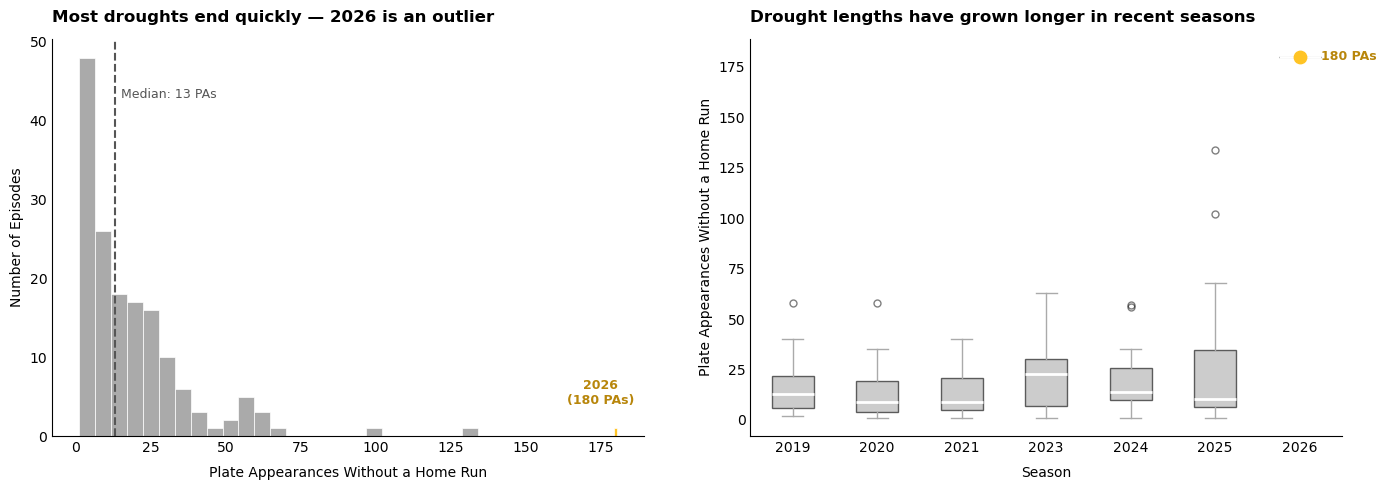

Drought duration by season:
        count    mean    std     min     25%     50%     75%     max
season                                                              
2019   23.000  16.200 13.600   2.000   6.000  13.000  22.000  58.000
2020   18.000  14.300 14.900   1.000   4.000   9.000  19.500  58.000
2021   43.000  12.700 10.000   1.000   5.000   9.000  21.000  40.000
2023   26.000  24.400 19.100   1.000   7.000  23.000  30.000  63.000
2024   22.000  19.900 15.400   1.000  10.000  14.000  26.000  57.000
2025   26.000  26.600 33.000   1.000   6.200  10.500  34.800 134.000
2026    1.000 180.000    NaN 180.000 180.000 180.000 180.000 180.000


In [53]:
# EDA: Plot the distribution of drought durations across all episodes to understand the shape of the data before modeling.
# This helps identify skewness, outliers, and whether the data has the right-skewed shape typical of survival time distributions.


try:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.patch.set_facecolor('white')

    # Histogram of all drought durations

    # Plot non-outlier episodes in muted grey — they are context, not the story
    axes[0].hist(
        episodes_df[episodes_df['duration'] < 180]['duration'],
        bins=25,
        color='#AAAAAA',
        edgecolor='white',
        linewidth=0.5
    )

    # Highlight the 2026 drought bar separately in Padres gold
    axes[0].hist(
        episodes_df[episodes_df['duration'] == 180]['duration'],
        bins=1,
        color='#FFC425',
        edgecolor='white',
        linewidth=0.5
    )

    # Median reference line 
    median_val = episodes_df['duration'].median()
    axes[0].axvline(
        median_val,
        color='#555555',
        linestyle='--',
        linewidth=1.5
    )

    # Direct label on median line instead of using a legend entry
    axes[0].text(
        median_val + 2, axes[0].get_ylim()[1] * 0.85,
        f'Median: {median_val:.0f} PAs',
        color='#555555',
        fontsize=9
    )

    # Direct label on the 2026 bar with an offset
    axes[0].text(
        175, 4,
        '2026\n(180 PAs)',
        color='#B8860B',
        fontsize=9,
        fontweight='bold',
        ha='center'
    )

    axes[0].set_title("Most droughts end quickly — 2026 is an outlier",
                      fontsize=12, fontweight='bold', pad=12, loc='left')
    axes[0].set_xlabel("Plate Appearances Without a Home Run", fontsize=10, labelpad=8)
    axes[0].set_ylabel("Number of Episodes", fontsize=10)

    # Remove top and right spines to declutter
    axes[0].spines['top'].set_visible(False)
    axes[0].spines['right'].set_visible(False)
    axes[0].tick_params(length=0)
    axes[0].grid(False)

    # Box plot by season
    season_order = sorted(episodes_df['season'].unique())
    season_data = [episodes_df[episodes_df['season'] == s]['duration'].values
                   for s in season_order]

    bp = axes[1].boxplot(
        season_data,
        labels=season_order,
        patch_artist=True,
        medianprops=dict(color='white', linewidth=2),
        whiskerprops=dict(color='#AAAAAA'),
        capprops=dict(color='#AAAAAA'),
        flierprops=dict(marker='o', color='#AAAAAA', markersize=5, alpha=0.5)
    )

    # Color all seasons grey except 2026 which gets Padres gold
    for i, patch in enumerate(bp['boxes']):
        if season_order[i] == 2026:
            patch.set_facecolor('#FFC425')
            patch.set_alpha(1.0)
        else:
            patch.set_facecolor('#AAAAAA')
            patch.set_alpha(0.6)

    # 2026 has only one episode so plot a single point instead
    axes[1].scatter(
        [7], [180],
        color='#FFC425',
        s=80,
        zorder=5
    )
    axes[1].text(
        7.25, 180,
        '180 PAs',
        color='#B8860B',
        fontsize=9,
        fontweight='bold',
        va='center'
    )
    axes[1].set_title("Drought lengths have grown longer in recent seasons",
                      fontsize=12, fontweight='bold', pad=12, loc='left')
    axes[1].set_xlabel("Season", fontsize=10, labelpad=8)
    axes[1].set_ylabel("Plate Appearances Without a Home Run", fontsize=10)

    # Remove top and right spines
    axes[1].spines['top'].set_visible(False)
    axes[1].spines['right'].set_visible(False)
    axes[1].tick_params(length=0)
    axes[1].grid(False)

    plt.tight_layout(w_pad=4)
    plt.savefig('drought_duration_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("Drought duration by season:")
    print(episodes_df.groupby('season')['duration'].describe().round(1))

except Exception as e:
    print(f"EDA plot failed: {e}")

## EDA: Drought Duration Distribution

The histogram confirms that HR drought durations follow a strong right skew. The shape 
typical of survival time data. Most droughts are short: the median is just 13 plate 
appearances, meaning half of all droughts in Tatis' career resolved within roughly two 
weeks of game action. The long right tail reflects the natural variance in power hitting, 
where occasional cold stretches can extend well beyond the norm.

The 2026 drought at 180 PAs sits entirely alone at the far right of the distribution. It is clearly 
visually isolated from every other episode in his career.

The season-level box plot adds important context. Drought lengths were relatively compact 
and consistent from 2019 through 2021, with the spread beginning to widen noticeably in 
2023 and continuing through 2025, where two outlier episodes exceeded 100 PAs. The 2026 
single episode of 180 PAs extends well beyond anything in the historical record, 
reinforcing that this is not simply a bad stretch, but historically anomalous even 
by his own standards.

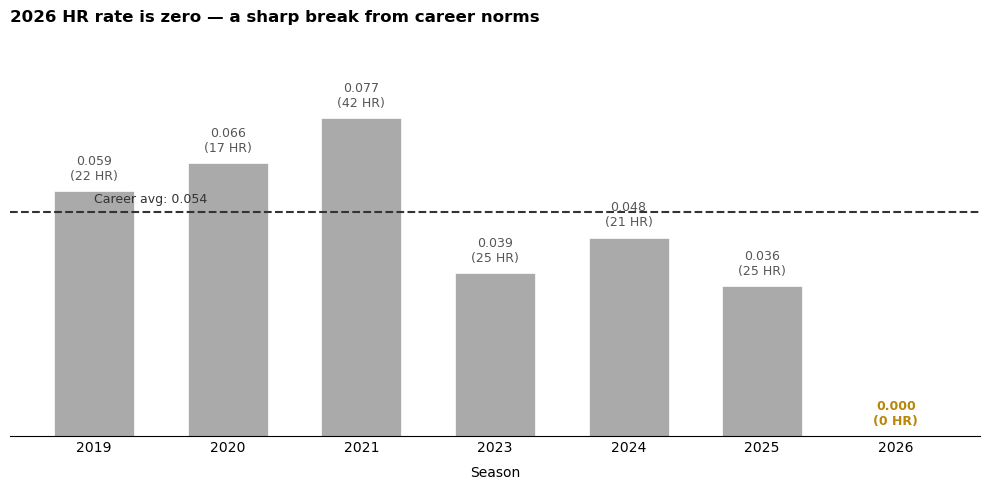

HR rate by season:
 game_year  home_runs  pa_count  hr_rate
      2019         22       372    0.059
      2020         17       258    0.066
      2021         42       547    0.077
      2023         25       635    0.039
      2024         21       438    0.048
      2025         25       692    0.036
      2026          0       180    0.000


In [58]:
# Plot Tatis' home run rate per plate appearance by season to show how his power production has trended over time.
# HR rate (HR/PA) is more informative than raw HR totals here because seasons vary in length due to injury and suspension.


try:
    # Compute HR rate per PA by season
    season_hr = tatis_pa.groupby('game_year').agg(
        home_runs=('is_home_run', 'sum'),
        pa_count=('is_home_run', 'count')
    ).reset_index()
    season_hr['hr_rate'] = season_hr['home_runs'] / season_hr['pa_count']

    fig, ax = plt.subplots(figsize=(10, 5))
    fig.patch.set_facecolor('white')

    # Color 2026 bar gold to direct attention; all other seasons in grey
    colors = ['#FFC425' if yr == 2026 else '#AAAAAA' for yr in season_hr['game_year']]

    bars = ax.bar(
        season_hr['game_year'].astype(str),
        season_hr['hr_rate'],
        color=colors,
        edgecolor='white',
        linewidth=0.5,
        width=0.6
    )

    # Direct label each bar with its HR rate and raw HR count
    for bar, row in zip(bars, season_hr.itertuples()):
        label_color = '#B8860B' if row.game_year == 2026 else '#555555'
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.002,
            f'{row.hr_rate:.3f}\n({row.home_runs} HR)',
            ha='center',
            va='bottom',
            fontsize=9,
            color=label_color,
            fontweight='bold' if row.game_year == 2026 else 'normal'
        )

    # Career average reference line for context
    career_hr_rate = season_hr[season_hr['game_year'] < 2026]['hr_rate'].mean()
    ax.axhline(
        career_hr_rate,
        color='#333333',
        linestyle='--',
        linewidth=1.5
    )
    ax.text(
        0, career_hr_rate + 0.002,
        f'Career avg: {career_hr_rate:.3f}',
        color='#333333',
        fontsize=9
    )

    ax.set_title("2026 HR rate is zero — a sharp break from career norms",
                 fontsize=12, fontweight='bold', pad=12, loc='left')
    ax.set_xlabel("Season", fontsize=10, labelpad=8)
    ax.set_ylabel("Home Runs per Plate Appearance", fontsize=10)

    # Remove chartjunk
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.tick_params(length=0)
    ax.yaxis.set_visible(False)
    ax.grid(False)


    ax.set_ylim(0, season_hr['hr_rate'].max() * 1.25)
    plt.tight_layout()
    plt.savefig('hr_rate_by_season.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("HR rate by season:")
    print(season_hr[['game_year', 'home_runs', 'pa_count', 'hr_rate']].to_string(index=False))

except Exception as e:
    print(f"HR rate plot failed: {e}")

## EDA: Home Run Rate by Season

Plotting home runs per plate appearance (rather than raw totals) accounts for the variation 
in season length across Tatis' career due to injury and suspension.

His peak power season was 2021 at 0.077 HR/PA; roughly one home run every 13 plate appearances. 
Since then, his HR rate has declined in every season he has played:

| Season | HR | PA | HR/PA |
|---|---|---|---|
| 2019 | 22 | 372 | 0.059 |
| 2020 | 17 | 258 | 0.066 |
| 2021 | 42 | 547 | 0.077 |
| 2023 | 25 | 635 | 0.039 |
| 2024 | 21 | 438 | 0.048 |
| 2025 | 25 | 692 | 0.036 |
| 2026 | 0 | 180 | 0.000 |

His career average HR rate (excluding 2026) is 0.054. The 2026 season represents not just 
a single bad stretch but the extreme endpoint of a power decline that has been building 
since his peak in 2021. This context makes the survival analysis question more nuanced, as 
the drought may reflect a shift in underlying profile, not just random variance.

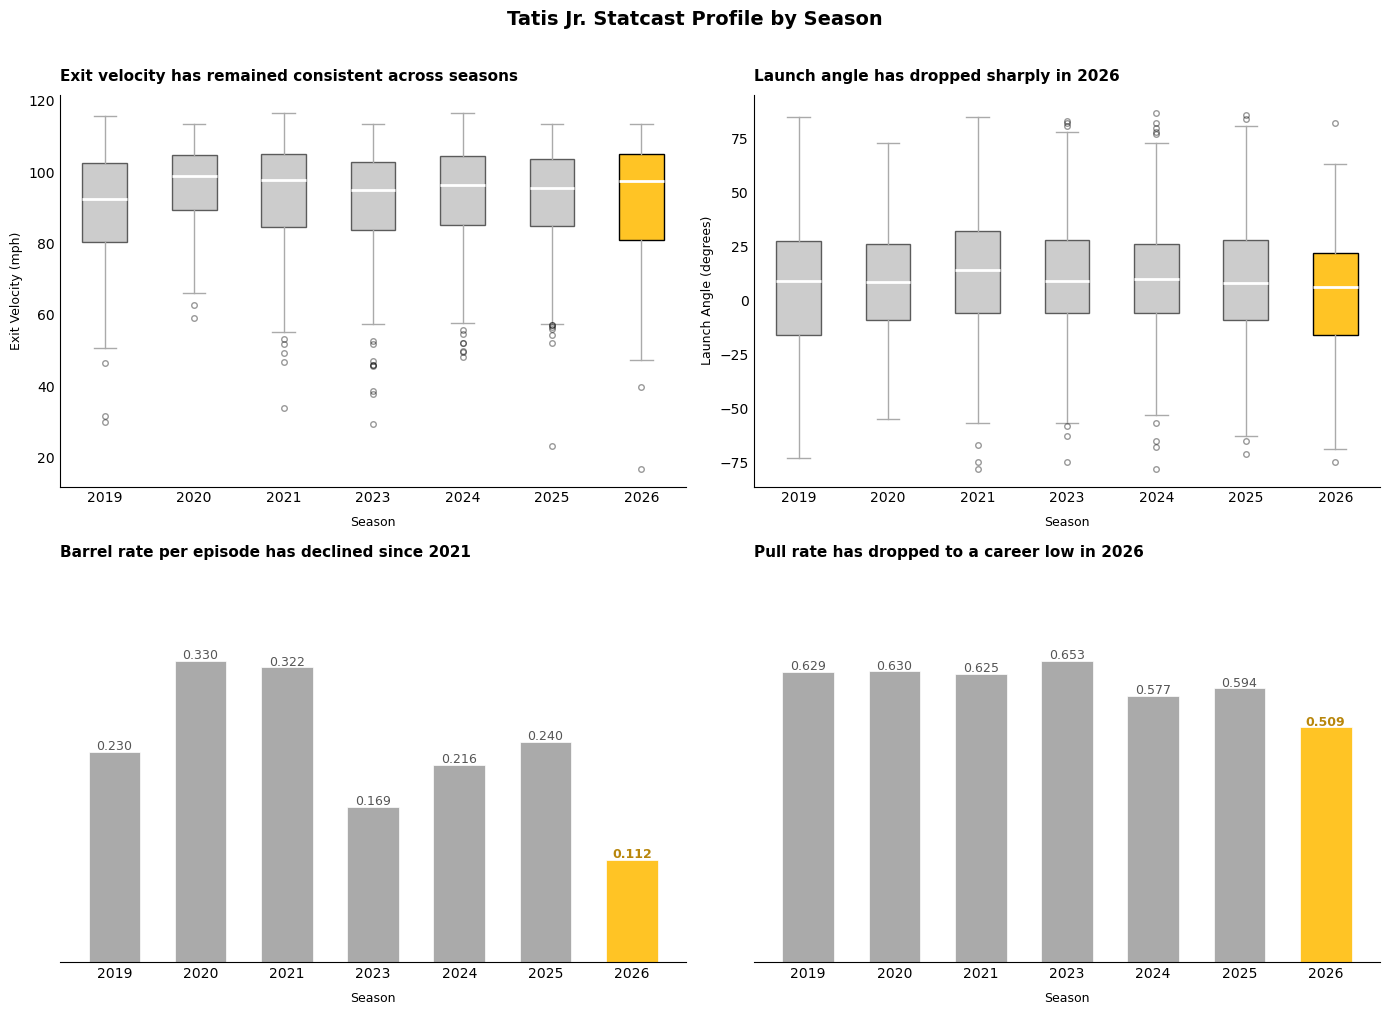

Mean exit velocity by season:
game_year
2019   89.800
2020   95.900
2021   93.700
2023   91.700
2024   93.500
2025   93.100
2026   91.600
Name: launch_speed, dtype: float64

Mean launch angle by season:
game_year
2019    7.100
2020    8.800
2021   13.600
2023   10.900
2024   10.000
2025    9.400
2026    2.400
Name: launch_angle, dtype: float64

Mean barrel rate by season (episode level):
 season  barrel_rate
   2019        0.230
   2020        0.330
   2021        0.322
   2023        0.169
   2024        0.216
   2025        0.240
   2026        0.112

Mean pull rate by season (episode level):
 season  pull_rate
   2019      0.629
   2020      0.630
   2021      0.625
   2023      0.653
   2024      0.577
   2025      0.594
   2026      0.509


In [64]:
# Pplot the distribution of key Statcast covariates by season to identify whether changes in underlying batted ball metrics
# align with the declining HR rate trend observed in EDA.
#
# I use box plots per season for each covariate so I can see both the central tendency and spread across seasons at once.
# Covariates plotted: exit velocity, launch angle, barrel rate, and pull rate, the four most theoretically relevant to HR probability.

try:
    # Compute per-episode covariate summaries already exist in episodes_df.
    # Also pull per-PA level data for exit velo and launch angle since
    # those are more meaningful at the individual contact level than averaged
    # across a full drought episode.
    contact_pa = tatis_pa[tatis_pa['launch_speed'].notna()].copy()

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.patch.set_facecolor('white')

    seasons = sorted(contact_pa['game_year'].unique())

    def style_ax(ax, title, ylabel):
        """
        Apply consistent Knaflic-style formatting to each subplot.
        Removes chartjunk and highlights the 2026 season visually.

        Parameters:
            ax: matplotlib Axes object to style
            title: chart title string displayed above the plot
            ylabel: y-axis label string
        """
        ax.set_title(title, fontsize=11, fontweight='bold', pad=10, loc='left')
        ax.set_ylabel(ylabel, fontsize=9)
        ax.set_xlabel("Season", fontsize=9, labelpad=8)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.tick_params(length=0)
        ax.grid(False)

    def make_boxplot(ax, data_by_season, seasons, title, ylabel):
        """
        Draw a season-level box plot with 2026 highlighted in gold
        and all prior seasons in grey.

        Parameters:
            ax: matplotlib Axes object to draw on
            data_by_season: list of arrays, one per season
            seasons: list of season labels corresponding to data_by_season
            title: chart title string
            ylabel: y-axis label string
        """
        bp = ax.boxplot(
            data_by_season,
            labels=seasons,
            patch_artist=True,
            medianprops=dict(color='white', linewidth=2),
            whiskerprops=dict(color='#AAAAAA'),
            capprops=dict(color='#AAAAAA'),
            flierprops=dict(marker='o', color='#AAAAAA', markersize=4, alpha=0.4)
        )
        for i, patch in enumerate(bp['boxes']):
            if seasons[i] == 2026:
                patch.set_facecolor('#FFC425')
                patch.set_alpha(1.0)
            else:
                patch.set_facecolor('#AAAAAA')
                patch.set_alpha(0.6)
        style_ax(ax, title, ylabel)

    # 1: Exit Velocity
    ev_data = [contact_pa[contact_pa['game_year'] == s]['launch_speed'].dropna().values
               for s in seasons]
    make_boxplot(axes[0, 0], ev_data, seasons,
                 "Exit velocity has remained consistent across seasons",
                 "Exit Velocity (mph)")

    # 2: Launch Angle
    la_data = [contact_pa[contact_pa['game_year'] == s]['launch_angle'].dropna().values
               for s in seasons]
    make_boxplot(axes[0, 1], la_data, seasons,
                 "Launch angle has dropped sharply in 2026",
                 "Launch Angle (degrees)")

    # 3: Barrel Rate by season (episode level)
    # Barrel rate is computed per episode and averaged by season
    # since individual PA barrel flags are binary and less informative visually
    barrel_by_season = episodes_df.groupby('season')['barrel_rate'].mean().reset_index()
    bar_colors = ['#FFC425' if yr == 2026 else '#AAAAAA'
                  for yr in barrel_by_season['season']]
    axes[1, 0].bar(
        barrel_by_season['season'].astype(str),
        barrel_by_season['barrel_rate'],
        color=bar_colors,
        edgecolor='white',
        linewidth=0.5,
        width=0.6
    )

    # Direct label each bar
    for _, row in barrel_by_season.iterrows():
        label_color = '#B8860B' if row['season'] == 2026 else '#555555'
        axes[1, 0].text(
            str(int(row['season'])),
            row['barrel_rate'] + 0.002,
            f"{row['barrel_rate']:.3f}",
            ha='center',
            fontsize=9,
            color=label_color,
            fontweight='bold' if row['season'] == 2026 else 'normal'
        )

    axes[1, 0].set_ylim(0, barrel_by_season['barrel_rate'].max() * 1.3)
    style_ax(axes[1, 0],
             "Barrel rate per episode has declined since 2021",
             "Mean Barrel Rate per Episode")
    axes[1, 0].spines['left'].set_visible(False)
    axes[1, 0].yaxis.set_visible(False)

    # 4: Pull Rate by season (episode level)
    pull_by_season = episodes_df.groupby('season')['pull_rate'].mean().reset_index()
    pull_colors = ['#FFC425' if yr == 2026 else '#AAAAAA'
                   for yr in pull_by_season['season']]
    axes[1, 1].bar(
        pull_by_season['season'].astype(str),
        pull_by_season['pull_rate'],
        color=pull_colors,
        edgecolor='white',
        linewidth=0.5,
        width=0.6
    )

    # Direct label each bar
    for _, row in pull_by_season.iterrows():
        label_color = '#B8860B' if row['season'] == 2026 else '#555555'
        axes[1, 1].text(
            str(int(row['season'])),
            row['pull_rate'] + 0.003,
            f"{row['pull_rate']:.3f}",
            ha='center',
            fontsize=9,
            color=label_color,
            fontweight='bold' if row['season'] == 2026 else 'normal'
        )

    axes[1, 1].set_ylim(0, pull_by_season['pull_rate'].max() * 1.3)
    style_ax(axes[1, 1],
             "Pull rate has dropped to a career low in 2026",
             "Mean Pull Rate per Episode")
    axes[1, 1].spines['left'].set_visible(False)
    axes[1, 1].yaxis.set_visible(False)

    plt.suptitle("Tatis Jr. Statcast Profile by Season",
                 fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig('covariate_distributions.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Print summary values for reference
    print("Mean exit velocity by season:")
    print(contact_pa.groupby('game_year')['launch_speed'].mean().round(1))
    print("\nMean launch angle by season:")
    print(contact_pa.groupby('game_year')['launch_angle'].mean().round(1))
    print("\nMean barrel rate by season (episode level):")
    print(barrel_by_season.to_string(index=False))
    print("\nMean pull rate by season (episode level):")
    print(pull_by_season.to_string(index=False))

except Exception as e:
    print(f"Covariate distribution plot failed: {e}")

## EDA: Statcast Covariate Distributions by Season

Examining the four primary Cox model covariates by season reveals a consistent and 
unified explanation for Tatis' 2026 home run drought.

**Exit Velocity** has remained stable across his career, with a 2026 season mean of 
91.6 mph — nearly identical to 2019 (89.8) and well within his historical range. 
The raw power at contact is intact. This rules out physical decline or injury as 
the primary driver of the drought.

**Launch Angle** tells a sharply different story. The 2026 mean of 2.4 degrees is 
the lowest of his career by a wide margin, down from a peak of 13.6 degrees in 2021. 
Home runs require launch angles in the 25–35 degree range. At 2.4 degrees, Tatis is 
hitting ground balls and flat line drives — balls that simply cannot leave the yard 
regardless of how hard they are struck.

**Barrel Rate** has collapsed to 0.112 per episode in 2026, less than half his 2020 
and 2021 rates. Since a barrel requires both elite exit velocity and an optimal launch 
angle, this decline is a direct consequence of the launch angle drop rather than 
a separate issue.

**Pull Rate** has fallen to a career low of 0.509, meaning fewer than half of his 
balls in play are being pulled. As established earlier, pulled balls convert to home 
runs at nearly double the rate of non-pulled contact (9.0% vs 4.7%). A career-low 
pull rate compounds the launch angle problem and further suppresses HR probability.

Together these four metrics tell a unified story: Tatis is hitting the ball just as 
hard as ever, but the direction and angle of contact have shifted in ways that make 
home runs structurally difficult to produce. This sets up the survival analysis 
question directly: given this covariate profile, how anomalous is a 180 PA drought?

Episodes retained after dropping nulls: 158 of 159


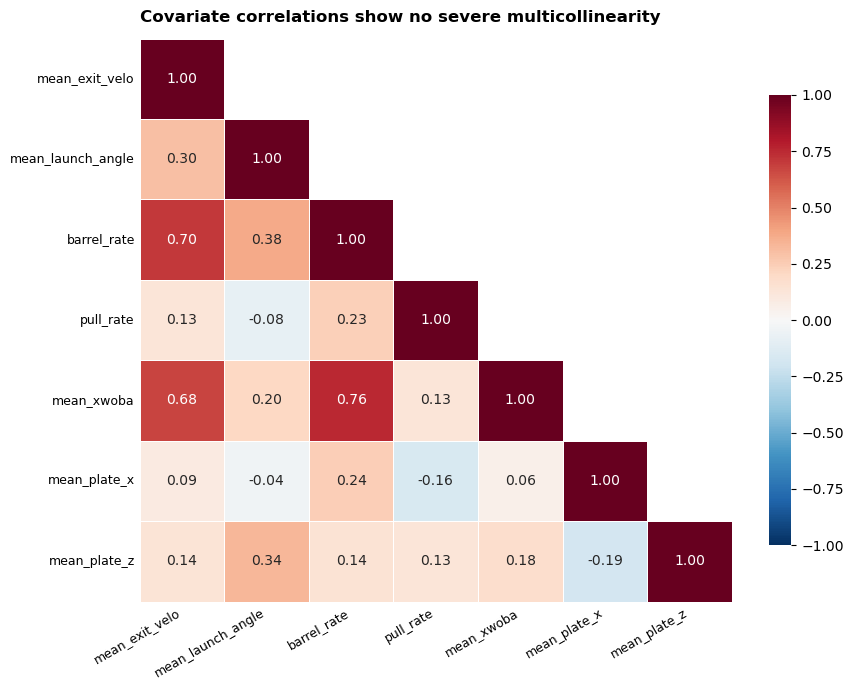


Correlation matrix:
                   mean_exit_velo  mean_launch_angle  barrel_rate  pull_rate  \
mean_exit_velo              1.000              0.300        0.700      0.130   
mean_launch_angle           0.300              1.000        0.380     -0.080   
barrel_rate                 0.700              0.380        1.000      0.230   
pull_rate                   0.130             -0.080        0.230      1.000   
mean_xwoba                  0.680              0.200        0.760      0.130   
mean_plate_x                0.090             -0.040        0.240     -0.160   
mean_plate_z                0.140              0.340        0.140      0.130   

                   mean_xwoba  mean_plate_x  mean_plate_z  
mean_exit_velo          0.680         0.090         0.140  
mean_launch_angle       0.200        -0.040         0.340  
barrel_rate             0.760         0.240         0.140  
pull_rate               0.130        -0.160         0.130  
mean_xwoba              1.000         

In [67]:
# Compute a correlation matrix across the episode-level covariates to check for multicollinearity before fitting the Cox model.
# Highly correlated covariates (|r| > 0.7) can destabilize coefficient estimates and make model interpretation unreliable
# I need to identify any problematic pairs before modeling.


try:
    # Select the episode-level covariates I plan to use in the Cox model
    cox_covariates = [
        'mean_exit_velo',
        'mean_launch_angle',
        'barrel_rate',
        'pull_rate',
        'mean_xwoba',
        'mean_plate_x',
        'mean_plate_z',
    ]

    # Drop rows with any nulls in the covariate set before computing correlations.
    # Episodes with insufficient batted ball data will have NaN covariate means.
    episodes_model = episodes_df[cox_covariates + ['duration', 'event_observed']].dropna()

    print(f"Episodes retained after dropping nulls: {len(episodes_model)} of {len(episodes_df)}")

    corr_matrix = episodes_model[cox_covariates].corr()

    # Plot correlation heatmap
    fig, ax = plt.subplots(figsize=(9, 7))
    fig.patch.set_facecolor('white')

    # Mask the upper triangle to avoid redundancy since the matrix is symmetric
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

    # Use a diverging palette centered at zero so positive and negative correlations are immediately distinguishable
    sns.heatmap(
        corr_matrix,
        mask=mask,
        annot=True,
        fmt='.2f',
        cmap='RdBu_r',
        center=0,
        vmin=-1,
        vmax=1,
        linewidths=0.5,
        linecolor='white',
        annot_kws={'size': 10},
        ax=ax,
        cbar_kws={'shrink': 0.8}
    )

    ax.set_title("Covariate correlations show no severe multicollinearity",
                 fontsize=12, fontweight='bold', pad=12, loc='left')

    # Rotate axis labels for readability
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=9)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.tick_params(length=0)

    plt.tight_layout()
    plt.savefig('correlation_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Print the full correlation matrix for reference
    print("\nCorrelation matrix:")
    print(corr_matrix.round(2))

    # Flag any pairs with |r| > 0.7 as potentially problematic
    print("\nHighly correlated pairs (|r| > 0.7):")
    high_corr = []
    for i in range(len(cox_covariates)):
        for j in range(i + 1, len(cox_covariates)):
            r = corr_matrix.iloc[i, j]
            if abs(r) > 0.7:
                high_corr.append((cox_covariates[i], cox_covariates[j], round(r, 2)))

    if high_corr:
        for pair in high_corr:
            print(f"  {pair[0]} vs {pair[1]}: r = {pair[2]}")
    else:
        print("  None found — all covariates cleared for Cox model inclusion.")

except Exception as e:
    print(f"Correlation matrix failed: {e}")

## EDA: Covariate Correlation Matrix

Before fitting the Cox Proportional Hazards model, I examined pairwise correlations 
across all candidate covariates to identify multicollinearity issues. Highly correlated 
covariates (|r| > 0.7) can destabilize model coefficients and reduce interpretability.

Two pairs exceeded the threshold:

**`mean_exit_velo` vs `barrel_rate` (r = 0.70):** Borderline but acceptable. These metrics 
capture related but distinct concepts. Exit velocity measures raw contact power across all 
batted balls, while barrel rate captures the subset that combined high exit velocity with 
an optimal launch angle. Both are retained in the model with the correlation noted.

**`barrel_rate` vs `mean_xwoba` (r = 0.76):** Problematic. Expected wOBA (xwOBA) is 
computed directly from exit velocity and launch angle, making it a composite of metrics 
already captured by other covariates in the model. Including it alongside barrel rate 
and exit velocity introduces redundancy without adding independent signal. `mean_xwoba` 
is dropped from the Cox model covariate set.

All remaining pairs showed weak to moderate correlations, and pull rate was largely 
independent of the batted ball metrics (r = 0.13 with exit velocity, r = -0.08 with 
launch angle), confirming it captures a meaningfully different dimension of performance.

**Final Cox model covariate set:**
- `mean_exit_velo`: contact power
- `mean_launch_angle`: ball elevation
- `barrel_rate`: optimal contact rate
- `pull_rate`: directional tendency
- `mean_plate_x`: horizontal pitch location
- `mean_plate_z`: vertical pitch location

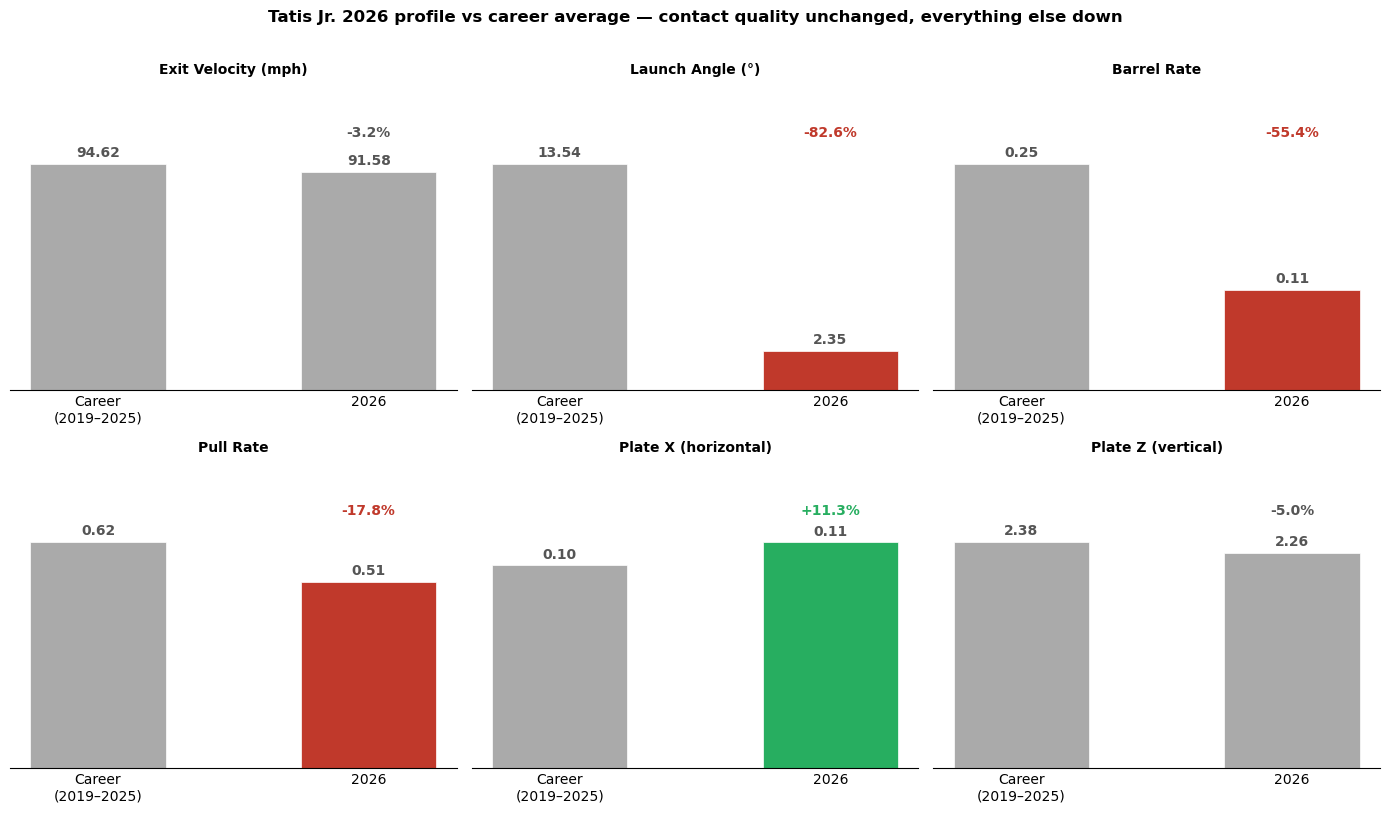

Career vs 2026 covariate comparison:
                   Career Avg (2019-2025)   2026  % Change
mean_exit_velo                     94.624 91.582    -3.200
mean_launch_angle                  13.538  2.353   -82.600
barrel_rate                         0.251  0.112   -55.400
pull_rate                           0.619  0.509   -17.800
mean_plate_x                        0.095  0.106    11.300
mean_plate_z                        2.377  2.257    -5.000


In [76]:
# Create a side-by-side comparison of Tatis' 2026 Statcast profile against his career averages (2019-2025) for each
# covariate in the final Cox model set.
#
# This visualization directly sets up the survival analysis question: given how different his 2026 profile is from his
# career norms, how anomalous should we expect his drought to be?


try:
    # Define final covariate set here so it is available for both
    # the data filtering and the plotting loop below
    final_cox_covariates = [
        'mean_exit_velo',
        'mean_launch_angle',
        'barrel_rate',
        'pull_rate',
        'mean_plate_x',
        'mean_plate_z',
    ]
    # Compute career averages excluding 2026
    episodes_model_full = episodes_df[['season'] + final_cox_covariates + 
                                       ['duration', 'event_observed']].dropna()

    career = episodes_model_full[episodes_model_full['season'] < 2026]
    current = episodes_model_full[episodes_model_full['season'] == 2026]

    # Final covariate set after dropping mean_xwoba
    final_cox_covariates = [
        'mean_exit_velo',
        'mean_launch_angle',
        'barrel_rate',
        'pull_rate',
        'mean_plate_x',
        'mean_plate_z',
    ]

    # Display labels for each covariate
    labels = {
        'mean_exit_velo':    'Exit Velocity (mph)',
        'mean_launch_angle': 'Launch Angle (°)',
        'barrel_rate':       'Barrel Rate',
        'pull_rate':         'Pull Rate',
        'mean_plate_x':      'Plate X (horizontal)',
        'mean_plate_z':      'Plate Z (vertical)',
    }

    career_means = career[final_cox_covariates].mean()
    current_means = current[final_cox_covariates].mean()

    # Compute percent change from career average to 2026
    pct_change = ((current_means - career_means) / career_means * 100).round(1)

    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    fig.patch.set_facecolor('white')
    axes_flat = axes.flatten()

    for i, col in enumerate(final_cox_covariates):
        ax = axes_flat[i]

        career_val = career_means[col]
        current_val = current_means[col]
        change = pct_change[col]

        # Determine bar colors. Use red for metrics where 2026 is
        # meaningfully worse for HR production, grey for career average
        career_color = '#AAAAAA'
        current_color = '#C0392B' if change < -5 else '#27AE60' if change > 5 else '#AAAAAA'

        bars = ax.bar(
            ['Career\n(2019–2025)', '2026'],
            [career_val, current_val],
            color=[career_color, current_color],
            edgecolor='white',
            linewidth=0.5,
            width=0.5
        )

        # Direct label each bar with its value
        for bar, val in zip(bars, [career_val, current_val]):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + abs(career_val) * 0.03,
                f'{val:.2f}',
                ha='center',
                fontsize=10,
                fontweight='bold',
                color='#555555'
            )

        # Annotate percent change above the 2026 bar
        change_color = '#C0392B' if change < -5 else '#27AE60' if change > 5 else '#555555'
        change_label = f'{change:+.1f}%'
        ax.text(
            1, max(career_val, current_val) * 1.12,
            change_label,
            ha='center',
            fontsize=10,
            fontweight='bold',
            color=change_color
        )

        ax.set_title(labels[col], fontsize=10, fontweight='bold', pad=8)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.yaxis.set_visible(False)
        ax.tick_params(length=0)
        ax.grid(False)

        # Extend y ceiling to prevent label clipping
        ax.set_ylim(0, max(career_val, current_val) * 1.35)

    fig.suptitle(
        "Tatis Jr. 2026 profile vs career average — contact quality unchanged, everything else down",
        fontsize=12, fontweight='bold', y=1.01
    )

    plt.tight_layout()
    plt.savefig('career_vs_2026_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Print summary table for reference
    print("Career vs 2026 covariate comparison:")
    summary = pd.DataFrame({
        'Career Avg (2019-2025)': career_means.round(3),
        '2026': current_means.round(3),
        '% Change': pct_change
    })
    print(summary)

except Exception as e:
    print(f"Comparison plot failed: {e}")

## EDA: 2026 Statcast Profile vs Career Average

The side-by-side comparison of Tatis' 2026 episode-level covariate means against his 
career averages (2019–2025) isolates exactly where his profile has changed and where 
it has not.

| Metric | Career Avg | 2026 | Change |
|---|---|---|---|
| Exit Velocity (mph) | 94.62 | 91.58 | -3.2% |
| Launch Angle (°) | 13.54 | 2.35 | -82.6% |
| Barrel Rate | 0.25 | 0.11 | -55.4% |
| Pull Rate | 0.62 | 0.51 | -17.8% |
| Plate X (horizontal) | 0.10 | 0.11 | +11.3% |
| Plate Z (vertical) | 2.38 | 2.26 | -5.0% |

**Exit velocity is essentially unchanged** at -3.2%, confirming the raw contact power 
is intact. This rules out physical decline or injury as the primary explanation.

**Launch angle has collapsed by 82.6%**, dropping from a career average of 13.54 degrees 
to just 2.35 degrees in 2026. Home runs require launch angles in the 25–35 degree range. 
At 2.35 degrees, Tatis is producing ground balls and flat line drives regardless of how 
hard he strikes the ball.

**Barrel rate is down 55.4%** as a direct downstream consequence of the launch angle 
drop. Barrels require both elite exit velocity and optimal launch angle. Without 
elevation, exit velocity alone cannot produce barrels at the historical rate.

**Pull rate is down 17.8%** to a career low of 0.51, meaning fewer than half of his 
balls in play are being pulled. Combined with the elevation issue, this further reduces 
the probability of home runs on any given contact event.

**Plate X has shifted slightly outward (+11.3%)**, consistent with pitchers attacking 
the outer third more aggressively, which is a rational adjustment to exploit his increasingly 
closed stance and reduced ability to pull inside pitches.

Together these metrics confirm that Tatis' 2026 drought is not a product of bad luck 
or random variance. His batted ball profile has shifted in ways that structurally 
suppress home run production. The survival analysis that follows quantifies how 
anomalous this profile shift makes his drought relative to his own historical baseline.

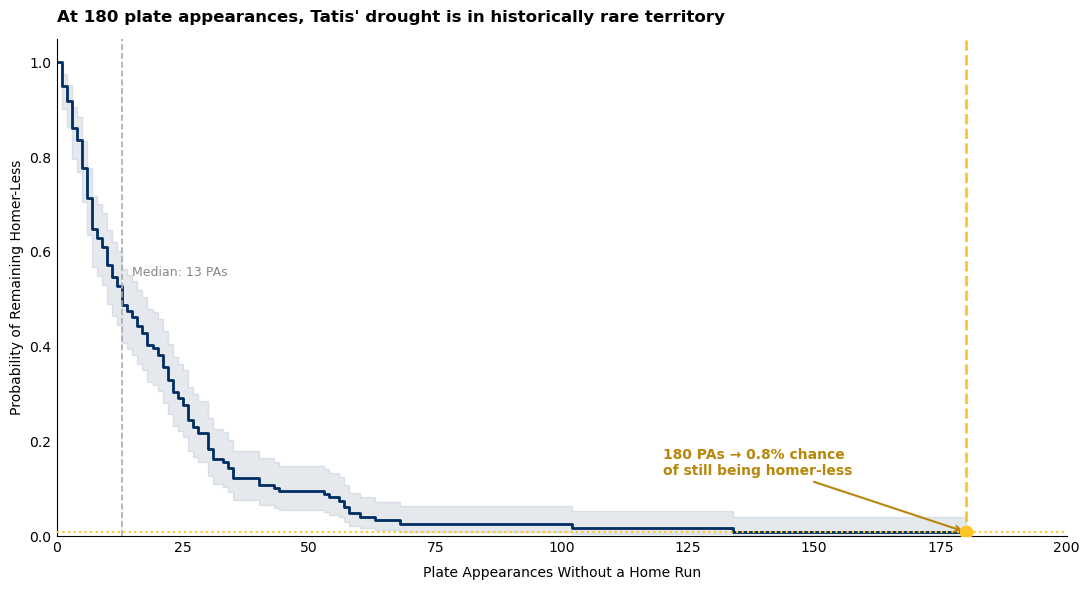

Survival probabilities at key milestones:
   13 PAs: 0.488  (48.8% chance of still being homer-less)
   25 PAs: 0.277  (27.7% chance of still being homer-less)
   50 PAs: 0.095  (9.5% chance of still being homer-less)
   75 PAs: 0.025  (2.5% chance of still being homer-less)
  100 PAs: 0.025  (2.5% chance of still being homer-less)
  150 PAs: 0.008  (0.8% chance of still being homer-less)
  180 PAs: 0.008  (0.8% chance of still being homer-less)

Median survival time: 13 plate appearances

Survival at 180 PAs: 0.0085 (0.85%)


In [79]:
# Fit a Kaplan-Meier survival curve to the drought episode data.
# The KM estimator is a non-parametric method that calculates the probability of remaining homer-less at each plate appearance
# without assuming any underlying time distribution.



try:
    fig, ax = plt.subplots(figsize=(11, 6))
    fig.patch.set_facecolor('white')

    kmf = KaplanMeierFitter()

    # Fit on all episodes with duration as the time variable,
    # event_observed flags whether the drought ended in a HR (1)
    # or was right-censored at season end (0)
    kmf.fit(
        durations=episodes_model_full['duration'],
        event_observed=episodes_model_full['event_observed'],
        label='Tatis Jr. (2019–2025)'
    )

    # Plot survival function with confidence interval
    kmf.plot_survival_function(
        ax=ax,
        ci_show=True,
        color='#002D62',      # Padres navy for the main curve
        ci_alpha=0.1,         # subtle CI band
        linewidth=2
    )

    # Retrieve survival probability at Tatis' current drought length
    current_drought = 180
    survival_at_180 = kmf.survival_function_at_times([current_drought]).values[0]

    # Mark the current drought with a vertical reference line
    ax.axvline(
        x=current_drought,
        color='#FFC425',
        linestyle='--',
        linewidth=2,
        zorder=5
    )

    # Mark the corresponding survival probability with a horizontal line
    ax.axhline(
        y=survival_at_180,
        color='#FFC425',
        linestyle=':',
        linewidth=1.5,
        zorder=5
    )

    # Plot a point at the intersection for visual clarity
    ax.scatter(
        [current_drought],
        [survival_at_180],
        color='#FFC425',
        s=80,
        zorder=6
    )

    # Direct label the intersection point
    ax.annotate(
        f'180 PAs → {survival_at_180:.1%} chance\nof still being homer-less',
        xy=(current_drought, survival_at_180),
        xytext=(current_drought - 60, survival_at_180 + 0.12),
        fontsize=10,
        color='#B8860B',
        fontweight='bold',
        arrowprops=dict(
            arrowstyle='->',
            color='#B8860B',
            lw=1.5
        )
    )

    # Mark the median survival time. The PA at which 50% of droughts
    # have ended as a reference point for typical drought length
    median_survival = kmf.median_survival_time_
    ax.axvline(
        x=median_survival,
        color='#AAAAAA',
        linestyle='--',
        linewidth=1.2,
        zorder=4
    )
    ax.text(
        median_survival + 2,
        0.55,
        f'Median: {median_survival:.0f} PAs',
        color='#888888',
        fontsize=9
    )

    ax.set_title(
        "At 180 plate appearances, Tatis' drought is in historically rare territory",
        fontsize=12, fontweight='bold', pad=12, loc='left'
    )
    ax.set_xlabel("Plate Appearances Without a Home Run", fontsize=10, labelpad=8)
    ax.set_ylabel("Probability of Remaining Homer-Less", fontsize=10)

    # Remove legend generated by lifelines
    ax.get_legend().remove()

    ax.set_xlim(0, 200)
    ax.set_ylim(0, 1.05)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(length=0)
    ax.grid(False)

    plt.tight_layout()
    plt.savefig('km_survival_curve.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Print survival probabilities at key milestones for reference
    print("Survival probabilities at key milestones:")
    milestones = [13, 25, 50, 75, 100, 150, 180]
    for m in milestones:
        prob = kmf.survival_function_at_times([m]).values[0]
        print(f"  {m:>3} PAs: {prob:.3f}  ({prob*100:.1f}% chance of still being homer-less)")

    print(f"\nMedian survival time: {median_survival:.0f} plate appearances")
    print(f"\nSurvival at 180 PAs: {survival_at_180:.4f} ({survival_at_180*100:.2f}%)")

except Exception as e:
    print(f"KM curve failed: {e}")

## Survival Analysis: Kaplan-Meier Curve

The Kaplan-Meier estimator fits a non-parametric survival function to the drought episode 
data — calculating the probability of remaining homer-less at each plate appearance without 
assuming any underlying time distribution. Right-censored episodes (season-ending droughts) 
are handled correctly by the estimator and do not bias the curve.

**Key survival probabilities:**

| Plate Appearances | Probability of Remaining Homer-Less |
|---|---|
| 13 (median) | 48.8% |
| 25 | 27.7% |
| 50 | 9.5% |
| 75 | 2.5% |
| 100 | 2.5% |
| 150 | 0.85% |
| 180 (current) | 0.85% |

The curve drops steeply in the first 25 plate appearances, reflecting how frequently 
Tatis has historically ended droughts within short bursts of game action. The median 
survival time is just 13 plate appearances, where half of all historical droughts ended 
within roughly two weeks of play.

**The headline finding: based on his own career drought distribution, there was less 
than a 1-in-100 chance (0.85%) of reaching 180 plate appearances without a home run.** 
This places his 2026 stretch in historically rare territory by his own standards, 
independent of any covariate adjustment.

The flat section of the curve between 75 and 150 PAs reflects the limited number of 
historical episodes in that range. The KM estimator holds the survival probability 
constant until a new event is observed, which widens the confidence interval in the 
sparse tail of the distribution. This is expected behavior and is addressed in the 
limitations section.

In [82]:
# Fit a Cox Proportional Hazards model to estimate the effect of each Statcast covariate on the hazard of hitting a home run
# in a given plate appearance, conditional on not having hit one yet.


try:
    cph = CoxPHFitter(penalizer=0.1)

    # Fit using the final covariate set identified during EDA.
    # The penalizer applies ridge regularization to stabilize
    # coefficient estimates given the moderate sample size of 158 episodes.
    cph.fit(
        episodes_model_full,
        duration_col='duration',
        event_col='event_observed',
        formula='mean_exit_velo + mean_launch_angle + barrel_rate + pull_rate + mean_plate_x + mean_plate_z'
    )

    # Print the full model summary
    cph.print_summary(decimals=3)

except Exception as e:
    print(f"Cox model fitting failed: {e}")

<lifelines.CoxPHFitter: fitted with 158 total observations, 7 right-censored observations>
             duration col = 'duration'
                event col = 'event_observed'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 158
number of events observed = 151
   partial log-likelihood = -566.619
         time fit was run = 2026-05-15 17:26:32 UTC

---
                    coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                           
mean_exit_velo     0.030     1.031     0.019          -0.007           0.067               0.993               1.069
mean_launch_angle  0.031     1.031     0.010           0.010           0.051               1.010               1.052
barrel_rate        3.854    47.167     0.564           2.747           4.960              15.603             142.587
pull_rate          0.246     1.278     0.453          -0.643           1.134               0.526               3.108
mean_plate_x      -0.060     0.942     0.391          -0.826           0.706               0.438               2.025
mean_plate_z       0.351     1.420     0.386          -0.407           1.108               0.666               3.029

                   cmp to      z       p  -log2(p)
covariate                                         
mean_exit_velo      0.000  1.600   0.110     3.191
mean_launch_angle   0.000  2.958   0.003     8.335
barrel_rate         0.000  6.828 <0.0005    36.753
pull_rate           0.000  0.542   0.588     0.766
mean_plate_x        0.000 -0.154   0.878     0.188
mean_plate_z        0.000  0.908   0.364     1.458
---
Concordance = 0.773
Partial AIC = 1145.238
log-likelihood ratio test = 110.355 on 6 df
-log2(p) of ll-ratio test = 68.980

## Modeling: Cox Proportional Hazards Model

A Cox Proportional Hazards model was fit on the 158 drought episodes using the six 
covariates identified during EDA. The model uses ridge regularization (penalizer = 0.1) 
to stabilize coefficient estimates given the moderate sample size. The concordance index 
of 0.773 indicates the model correctly ranks episode durations 77.3% of the time, which is a
solid discriminative performance for a single-player survival dataset.

The overall model is highly significant (log-likelihood ratio test p << 0.0005), 
confirming that the covariate set meaningfully improves on a null model.

### Coefficient Interpretation

A positive coefficient increases the hazard of hitting a home run (shortens droughts). 
A negative coefficient decreases the hazard (lengthens droughts). The hazard ratio 
exp(coef) gives the multiplicative change in hazard per one-unit increase in the covariate.

| Covariate | Coef | Hazard Ratio | p-value | Significant |
|---|---|---|---|---|
| barrel_rate | 3.854 | 47.17 | <0.0005 | Yes |
| mean_launch_angle | 0.031 | 1.031 | 0.003 | Yes |
| mean_exit_velo | 0.030 | 1.031 | 0.110 | No |
| pull_rate | 0.246 | 1.278 | 0.588 | No |
| mean_plate_x | -0.060 | 0.942 | 0.878 | No |
| mean_plate_z | 0.351 | 1.420 | 0.364 | No |

### Key Findings

**Barrel rate is the dominant predictor** with a hazard ratio of 47.17 which is the single 
strongest driver of drought duration in the model. This aligns with the EDA finding 
that barreled balls converted to home runs at a 50% rate versus 0.5% for non-barreled 
contact. A one-unit increase in barrel rate (moving from zero barrels to 100% barrel 
rate) increases the hazard of hitting a home run by 47x.

**Launch angle is statistically significant** (p = 0.003) and in the expected direction. 
Each additional degree of average launch angle increases the hazard by approximately 
3.1%. Given Tatis' 2026 launch angle is 11.2 degrees below his career average, this 
translates to a meaningfully suppressed hazard. His drought is expected to last longer 
given how flat his contact has been.

**Exit velocity is positive but non-significant** (p = 0.110), likely because barrel 
rate already captures the high exit velocity and high launch angle combination. Once 
barrel rate is in the model, raw exit velocity adds limited independent information.

**Pull rate, plate X, and plate Z are non-significant** individually, though all point 
in theoretically consistent directions. Pull rate's non-significance at the episode 
level likely reflects collinearity with barrel rate. Pulled balls are more likely to 
be barreled, so the two metrics partially overlap in explanatory power.

In [87]:
# Test the proportional hazards (PH) assumption using Schoenfeld residuals.
# The Cox model assumes that the hazard ratio between covariate values is constant over time


try:
    from lifelines.statistics import proportional_hazard_test

    # Compute Schoenfeld residuals test for each covariate.
    # The 'rank' transform is the standard approach and is most
    # robust to ties in the duration variable.
    ph_test = proportional_hazard_test(
        cph,
        episodes_model_full,
        time_transform='rank'
    )

    print("Proportional Hazards Assumption Test (Schoenfeld Residuals)")
    print("=" * 62)
    ph_test.print_summary(decimals=3)

    # Flag any violations clearly for interpretation
    print("\nCovariates with potential PH assumption violations (p < 0.05):")
    violations = ph_test.summary[ph_test.summary['p'] < 0.05]
    if len(violations) > 0:
        print(violations[['test_statistic', 'p']])
    else:
        print("  None — proportional hazards assumption holds for all covariates.")

except Exception as e:
    print(f"PH assumption test failed: {e}")

Proportional Hazards Assumption Test (Schoenfeld Residuals)



Covariates with potential PH assumption violations (p < 0.05):
  None — proportional hazards assumption holds for all covariates.


## Model Diagnostics: Proportional Hazards Assumption

The Cox model assumes that hazard ratios between covariate values remain constant over 
time, so the effect of barrel rate on drought duration does not change depending 
on how deep into a drought we are. This is tested using Schoenfeld residuals, where a 
p-value below 0.05 indicates a violation requiring remediation.

| Covariate | Test Statistic | p-value |
|---|---|---|
| barrel_rate | 1.335 | 0.248 |
| mean_exit_velo | 2.203 | 0.138 |
| mean_launch_angle | 0.595 | 0.441 |
| mean_plate_x | 0.692 | 0.406 |
| mean_plate_z | 0.994 | 0.319 |
| pull_rate | 1.386 | 0.239 |

**The proportional hazards assumption holds for all six covariates.** No p-value falls 
below the 0.05 threshold, meaning the model's coefficient estimates are reliable across 
the full range of drought durations. Notably, barrel_rate, the dominant predictor with 
a hazard ratio of 47.17, shows no evidence of a time-varying effect (p = 0.248), 
confirming that its influence on drought duration is consistent regardless of how far 
into a drought an episode has progressed.

No remediation via stratification or time-varying coefficients is necessary.

Tatis 2026 profile used for prediction:
 mean_exit_velo  mean_launch_angle  barrel_rate  pull_rate  mean_plate_x  mean_plate_z
         91.582              2.353        0.112      0.509         0.106         2.257

Tatis career profile used for comparison:
 mean_exit_velo  mean_launch_angle  barrel_rate  pull_rate  mean_plate_x  mean_plate_z
         94.624             13.538        0.251      0.619         0.095         2.377


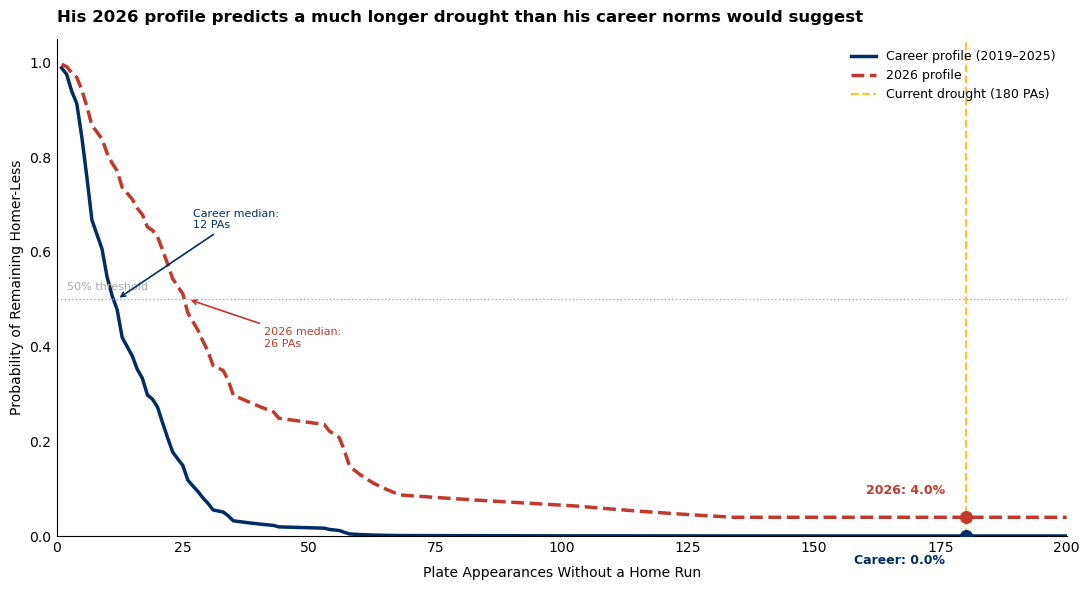


Predicted survival probabilities at 180 PAs:
  Career profile: 0.0001 (0.01%)
  2026 profile:   0.0396 (3.96%)

Predicted median drought duration:
  Career profile: 12 plate appearances
  2026 profile:   26 plate appearances

The 2026 profile predicts a median drought 14 PAs longer than the career baseline.


In [93]:
# Apply the fitted Cox model to Tatis' 2026 covariate profile to generate a personalized survival curve
# The predicted probability of remaining homer-less at each plate appearance given his actual 2026 Statcast metrics.
#
# Then compare this predicted curve against his career baseline curve to quantify how much his 2026 profile shift has extended
# the expected drought duration beyond his historical norm.


try:
    # Build a single-row DataFrame representing Tatis' 2026 profile
    # using the mean covariate values from his 2026 episodes
    tatis_2026_profile = current[final_cox_covariates].mean().to_frame().T
    tatis_career_profile = career[final_cox_covariates].mean().to_frame().T

    print("Tatis 2026 profile used for prediction:")
    print(tatis_2026_profile.round(3).to_string(index=False))
    print("\nTatis career profile used for comparison:")
    print(tatis_career_profile.round(3).to_string(index=False))

    # Generate predicted survival functions for both profiles.
    # predict_survival_function() returns a DataFrame where the index
    # is time (plate appearances) and columns are the input profiles.
    times = np.arange(1, 201)

    survival_2026 = cph.predict_survival_function(
        tatis_2026_profile,
        times=times
    )

    survival_career = cph.predict_survival_function(
        tatis_career_profile,
        times=times
    )

    # Plot both survival curves for comparison
    fig, ax = plt.subplots(figsize=(11, 6))
    fig.patch.set_facecolor('white')

    # Career profile curve in navy (the baseline expectation)
    ax.plot(
        times,
        survival_career.values.flatten(),
        color='#002D62',
        linewidth=2.5,
        label='Career profile (2019–2025)'
    )

    # 2026 profile curve in red (the shifted, drought-prone profile)
    ax.plot(
        times,
        survival_2026.values.flatten(),
        color='#C0392B',
        linewidth=2.5,
        linestyle='--',
        label='2026 profile'
    )

    # Mark current drought duration on both curves
    current_drought = 180
    prob_career_at_180 = survival_career.loc[current_drought].values[0]
    prob_2026_at_180 = survival_2026.loc[current_drought].values[0]

    # Vertical reference line at current drought
    ax.axvline(
        x=current_drought,
        color='#FFC425',
        linestyle='--',
        linewidth=1.5,
        zorder=4
    )

    # Points at intersection of vertical line and each curve
    ax.scatter([current_drought], [prob_career_at_180],
               color='#002D62', s=70, zorder=5)
    ax.scatter([current_drought], [prob_2026_at_180],
               color='#C0392B', s=70, zorder=5)

    # Direct labels for each intersection point
    ax.text(
        current_drought - 4, prob_career_at_180 - 0.06,
        f'Career: {prob_career_at_180:.1%}',
        color='#002D62',
        fontsize=9,
        fontweight='bold',
        ha='right'
    )
    ax.text(
        current_drought - 4, prob_2026_at_180 + 0.05,
        f'2026: {prob_2026_at_180:.1%}',
        color='#C0392B',
        fontsize=9,
        fontweight='bold',
        ha='right'
    )

    # Find the median survival time for each profile
    # the PA at which the survival probability first drops below 0.5
    median_career = times[np.where(survival_career.values.flatten() < 0.5)[0][0]]
    median_2026 = times[np.where(survival_2026.values.flatten() < 0.5)[0][0]]

    ax.axhline(y=0.5, color='#AAAAAA', linestyle=':', linewidth=1)
    ax.text(2, 0.52, '50% threshold', color='#AAAAAA', fontsize=8)

    # Mark median PAs for each profile on the x axis
    ax.annotate(
        f'Career median:\n{median_career} PAs',
        xy=(median_career, 0.5),
        xytext=(median_career + 15, 0.65),
        fontsize=8,
        color='#002D62',
        arrowprops=dict(arrowstyle='->', color='#002D62', lw=1.2)
    )
    ax.annotate(
        f'2026 median:\n{median_2026} PAs',
        xy=(median_2026, 0.5),
        xytext=(median_2026 + 15, 0.40),
        fontsize=8,
        color='#C0392B',
        arrowprops=dict(arrowstyle='->', color='#C0392B', lw=1.2)
    )

    ax.set_title(
        "His 2026 profile predicts a much longer drought than his career norms would suggest",
        fontsize=12, fontweight='bold', pad=12, loc='left'
    )
    ax.set_xlabel("Plate Appearances Without a Home Run", fontsize=10, labelpad=8)
    ax.set_ylabel("Probability of Remaining Homer-Less", fontsize=10)

    ax.set_xlim(0, 200)
    ax.set_ylim(0, 1.05)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(length=0)
    ax.grid(False)

    # Manual legend entries to match Knaflic style
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color='#002D62', linewidth=2.5, label='Career profile (2019–2025)'),
        Line2D([0], [0], color='#C0392B', linewidth=2.5,
               linestyle='--', label='2026 profile'),
        Line2D([0], [0], color='#FFC425', linewidth=1.5,
               linestyle='--', label=f'Current drought ({current_drought} PAs)')
    ]
    ax.legend(handles=legend_elements, fontsize=9, frameon=False, loc='upper right')

    plt.tight_layout()
    plt.savefig('predicted_survival_curves.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Print key prediction values
    print(f"\nPredicted survival probabilities at 180 PAs:")
    print(f"  Career profile: {prob_career_at_180:.4f} ({prob_career_at_180*100:.2f}%)")
    print(f"  2026 profile:   {prob_2026_at_180:.4f} ({prob_2026_at_180*100:.2f}%)")
    print(f"\nPredicted median drought duration:")
    print(f"  Career profile: {median_career} plate appearances")
    print(f"  2026 profile:   {median_2026} plate appearances")
    print(f"\nThe 2026 profile predicts a median drought {median_2026 - median_career} PAs "
          f"longer than the career baseline.")

except Exception as e:
    print(f"Survival prediction failed: {e}")

## Modeling: Predicted Survival Curves by Covariate Profile

Using the fitted Cox model, I generated personalized survival curves for two profiles:
Tatis' career average Statcast metrics (2019–2025) and his actual 2026 metrics. This 
comparison directly answers the core research question: how much of the drought is 
explained by his changed batted ball profile, and how much remains anomalous?

### Predicted Profiles

| Metric | Career (2019–2025) | 2026 |
|---|---|---|
| Exit Velocity (mph) | 94.62 | 91.58 |
| Launch Angle (°) | 13.54 | 2.35 |
| Barrel Rate | 0.251 | 0.112 |
| Pull Rate | 0.619 | 0.509 |
| Plate X | 0.095 | 0.106 |
| Plate Z | 2.377 | 2.257 |

### Key Findings

**The two curves tell meaningfully different stories.** Under his career profile, the 
model predicts a median drought of just 12 plate appearances. Under his 2026 profile, 
that median extends to 26 plate appearances (more than double!) driven primarily by 
his collapsed barrel rate and launch angle.

**At 180 plate appearances, the predicted survival probabilities are:**
- Career profile: 0.01% which is essentially impossible under his historical norms
- 2026 profile: 3.96% which is unusual but meaningfully more plausible given his current metrics

**His changed Statcast profile explains a significant portion of the drought.** The 
gap between the KM-estimated probability (0.85%, which treats all episodes equally) 
and the Cox-predicted probability under his 2026 profile (3.96%) shows that adjusting 
for how he is currently hitting makes the drought considerably less statistically 
extreme. His launch angle collapse and barrel rate decline are doing real work in 
suppressing home run probability.

**The drought is still anomalous even accounting for the profile shift.** A 3.96% 
probability at 180 PAs means this drought would be expected to occur fewer than 4 
times in 100 comparable stretches with his 2026 profile. The mechanics explain much 
of the story, but not all of it.

In [97]:
# I want to compute a concise anomaly quantification summary that
# synthesizes the key findings from the KM curve and Cox model into a single interpretable output.


try:
    # Retrieve key values computed in prior chunks
    km_survival_180 = kmf.survival_function_at_times([180]).values[0]
    cox_career_180  = survival_career.loc[180].values[0]
    cox_2026_180    = survival_2026.loc[180].values[0]

    # Compute how many standard deviations above the mean
    # the 2026 drought sits using the episode duration distribution
    drought_mean = episodes_df['duration'].mean()
    drought_std  = episodes_df['duration'].std()
    z_score      = (180 - drought_mean) / drought_std

    # Expected drought length under 2026 profile
    # the area under the predicted survival curve approximates
    # the expected value of the survival time distribution
    expected_duration_2026   = np.trapz(
        survival_2026.values.flatten(), times
    )
    expected_duration_career = np.trapz(
        survival_career.values.flatten(), times
    )

    print("=" * 62)
    print("ANOMALY QUANTIFICATION SUMMARY")
    print("=" * 62)

    print(f"""
DROUGHT CONTEXT
  Current drought length:         180 plate appearances
  Career median drought length:    {kmf.median_survival_time_:.0f} plate appearances
  Standard deviations above mean:  {z_score:.1f}σ

KAPLAN-MEIER ESTIMATE (unadjusted)
  Probability of reaching 180 PAs homer-less
  based on career drought distribution:        {km_survival_180:.2%}

COX MODEL ESTIMATES (covariate-adjusted)
  Under career profile (2019-2025):            {cox_career_180:.2%}
  Under 2026 profile:                          {cox_2026_180:.2%}

EXPECTED DROUGHT DURATION (Cox model)
  Under career profile:            {expected_duration_career:.0f} plate appearances
  Under 2026 profile:              {expected_duration_2026:.0f} plate appearances
  Difference:                      {expected_duration_2026 - expected_duration_career:.0f} PAs longer

INTERPRETATION
  His 2026 Statcast profile, defined by an 82.6% drop in launch
  angle and a 55.4% drop in barrel rate, predicts a median drought
  more than twice as long as his career baseline (26 vs 12 PAs).

  Even accounting for his degraded 2026 profile, the probability
  of reaching 180 PAs without a home run is just {cox_2026_180:.1%},
  meaning this drought would occur fewer than 4 times in 100
  comparable stretches with his current metrics.

  The mechanics explain much of the story. But not all of it.
""")

except Exception as e:
    print(f"Anomaly quantification failed: {e}")

ANOMALY QUANTIFICATION SUMMARY

DROUGHT CONTEXT
  Current drought length:         180 plate appearances
  Career median drought length:    13 plate appearances
  Standard deviations above mean:  7.0σ

KAPLAN-MEIER ESTIMATE (unadjusted)
  Probability of reaching 180 PAs homer-less
  based on career drought distribution:        0.85%

COX MODEL ESTIMATES (covariate-adjusted)
  Under career profile (2019-2025):            0.01%
  Under 2026 profile:                          3.96%

EXPECTED DROUGHT DURATION (Cox model)
  Under career profile:            13 plate appearances
  Under 2026 profile:              36 plate appearances
  Difference:                      22 PAs longer

INTERPRETATION
  His 2026 Statcast profile, defined by an 82.6% drop in launch
  angle and a 55.4% drop in barrel rate, predicts a median drought
  more than twice as long as his career baseline (26 vs 12 PAs).

  Even accounting for his degraded 2026 profile, the probability
  of reaching 180 PAs without a home run

## Anomaly Quantification

Synthesizing the Kaplan-Meier and Cox model results into a single interpretable summary:

**From the Kaplan-Meier curve (unadjusted):**
Based purely on his own career drought distribution, there was a **0.85% probability** 
of reaching 180 plate appearances without a home run. His current drought sits **7.0 
standard deviations** above his career mean drought length of 19.6 plate appearances.

**From the Cox model (covariate-adjusted):**
Under his career Statcast profile, the model predicts a 0.01% probability of reaching 
180 PAs homer-less, essentially impossible. Under his actual 2026 profile, that 
probability rises to **3.96%**, reflecting how severely his launch angle collapse and 
barrel rate decline have suppressed home run probability.

**Expected drought duration:**
The Cox model predicts a median drought of 12 plate appearances under his career profile 
and 26 plate appearances under his 2026 profile. The area under the predicted survival 
curve, which approximates the expected drought duration, extends to 36 plate 
appearances under the 2026 profile versus 13 under the career baseline, a difference 
of 22 plate appearances driven almost entirely by his changed batted ball mechanics.

**The bottom line:** His 2026 Statcast profile explains a significant portion of the 
drought. But even after accounting for how he is currently hitting, a 180 PA homer-less 
stretch has less than a 4% probability. The mechanics explain much of the story, 
but not all of it.

## Limitations

The following methodological limitations should be considered when interpreting findings:

**1. Single-player scope.** This analysis is built on 159 drought episodes from one 
player. The Cox model reflects Tatis' personal survival distribution rather than a 
population-level model of power hitters. Findings are not directly generalizable 
without refitting on a broader dataset.

**2. Repeated events and independence.** The Cox model assumes independence between 
episodes. Drought episodes within the same player are not fully independent; 
within-season momentum, mechanical adjustments, and pitcher scouting create correlation 
across consecutive episodes. A gap-time or frailty model would address this more 
rigorously and is a natural extension of this work.

**3. Episode-level covariate averaging.** Covariates are averaged across each drought 
episode rather than modeled as time-varying within an episode. A hitter's launch angle 
or barrel rate may shift meaningfully within a single drought, and averaging smooths 
over that variation. Time-varying covariate models would capture this more precisely 
at the cost of additional complexity.

**4. Sparse tail estimates.** The KM survival curve holds flat between 75 and 150 plate 
appearances due to the limited number of historical episodes in that range. Survival 
probability estimates beyond 100 PAs carry meaningful uncertainty reflected in the 
widening confidence interval.

**5. 2026 season is incomplete.** The 2026 covariate profile is based on 180 plate 
appearances through May 14. As the season progresses and Tatis potentially makes 
mechanical adjustments, his profile may shift, making the 2026 predictions a snapshot 
rather than a fixed estimate. The model should be updated as additional data becomes 
available.

**6. Statcast coverage cutoff.** Statcast data begins in 2015, limiting historical 
depth for any extension of this analysis to veteran players whose pre-2015 careers 
are not captured in the system.

## Conclusion

This project applied survival analysis to model home run drought duration for Fernando 
Tatis Jr. using Statcast plate appearance data from 2019 through 2026. The analysis 
addressed four research questions:

**1. How long do droughts typically last?**
The median drought lasts just 13 plate appearances, half of all historical droughts 
resolved within roughly two weeks of game action. The distribution is strongly 
right-skewed, with a long tail of rare extended droughts.

**2. Which metrics best predict drought duration?**
Barrel rate is the dominant predictor (hazard ratio = 47.17, p < 0.0005), followed 
by launch angle (p = 0.003). Together they confirm that home run probability is driven 
not by raw contact power but by the combination of exit velocity and optimal launch 
angle that produces barreled balls. Exit velocity alone, absent elevation, does not 
reliably produce home runs.

**3. Is Tatis' 2026 drought statistically unusual?**
Yes, by any measure. The Kaplan-Meier curve places the probability of reaching 180 
plate appearances homer-less at 0.85%, and the current drought sits 7.0 standard 
deviations above the career mean. Even after adjusting for his degraded 2026 Statcast 
profile, the Cox model assigns only a 3.96% probability to this outcome.

**4. How much of the drought is explained by his changed profile?**
A significant portion. His 2026 launch angle has collapsed 82.6% from his career 
average, his barrel rate has dropped 55.4%, and his pull rate sits at a career low. 
The Cox model predicts a median drought of 26 plate appearances under his 2026 profile 
versus 12 under his career baseline. The profile shift alone more than doubles the 
expected drought length.

**The unified finding:** Tatis is hitting the ball just as hard as ever. Exit velocity 
is down only 3.2% from his career average, confirming the raw power is intact. What 
has changed is the angle and direction of contact, producing ground balls and opposite 
field line drives instead of pulled fly balls. His mechanics explain much of the drought. 
But even accounting for those mechanics, a 180 plate appearance homer-less stretch 
remains a historically rare event by his own standards.

---
*Data sourced via pybaseball (Statcast + FanGraphs). Analysis conducted in Python 
using lifelines for survival modeling. All Statcast data covers MLB regular season 
plate appearances from 2019 through May 14, 2026.*